In [6]:
from google.colab import drive

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [7]:
import pandas as pd
df = pd.read_csv("traffic_flow_clustering_dataset.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)


Dataset loaded successfully!
Shape: (600, 8)


In [8]:
from google.colab import files

uploaded = files.upload()

In [9]:
# Display the first 5 rows

df.head()

,Record_ID,Hour,Day_of_Week,Vehicle_Count,Average_Speed_kmph,Traffic_Density_veh_per_km,Road_Occupancy_percent,Traffic_Condition
0,1,5,0,19.0,53.63,16.95,10.64,Low
1,2,13,1,282.0,21.52,58.25,64.57,High
2,3,21,6,114.0,36.43,27.77,39.43,Moderate
3,4,3,0,125.0,47.47,52.63,26.83,Moderate
4,5,23,5,22.0,63.71,13.69,14.19,Low


In [10]:
# Display number of rows and columns

print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 600
Number of columns: 8


In [11]:
# Display all column names

print(df.columns.tolist())

['Record_ID', 'Hour', 'Day_of_Week', 'Vehicle_Count', 'Average_Speed_kmph', 'Traffic_Density_veh_per_km', 'Road_Occupancy_percent', 'Traffic_Condition']


In [12]:
# Display information about columns and their data types

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 8 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Record_ID                   600 non-null    int64  
 1   Hour                        600 non-null    int64  
 2   Day_of_Week                 600 non-null    int64  
 3   Vehicle_Count               596 non-null    float64
 4   Average_Speed_kmph          596 non-null    float64
 5   Traffic_Density_veh_per_km  596 non-null    float64
 6   Road_Occupancy_percent      600 non-null    float64
 7   Traffic_Condition           600 non-null    object 
dtypes: float64(4), int64(3), object(1)
memory usage: 37.6+ KB


In [13]:
# Generate statistical summary

df.describe()

,Record_ID,Hour,Day_of_Week,Vehicle_Count,Average_Speed_kmph,Traffic_Density_veh_per_km,Road_Occupancy_percent
count,600.000000,600.000000,600.00000,596.000000,596.000000,596.000000,600.000000
mean,300.500000,11.886667,3.01500,116.718121,42.938272,40.016074,39.819000
std,173.349358,6.961172,2.00453,77.592955,15.391792,21.775617,21.368777
min,1.000000,0.000000,0.00000,15.000000,10.030000,10.000000,10.120000
25%,150.750000,6.000000,1.00000,58.000000,30.970000,22.477500,22.535000
50%,300.500000,12.000000,3.00000,89.000000,44.750000,33.905000,32.525000
75%,450.250000,18.000000,5.00000,161.000000,54.607500,53.952500,54.132500
max,600.000000,23.000000,6.00000,300.000000,69.960000,89.820000,89.700000


In [14]:
# Check the number of missing values in each column

print(df.isnull().sum())

Record_ID                     0
Hour                          0
Day_of_Week                   0
Vehicle_Count                 4
Average_Speed_kmph            4
Traffic_Density_veh_per_km    4
Road_Occupancy_percent        0
Traffic_Condition             0
dtype: int64


In [15]:
# Count duplicate rows

print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


In [16]:
# Display unique traffic conditions

print(df["Traffic_Condition"].unique())

['Low' 'High' 'Moderate']


In [17]:
# Count the number of records in each traffic condition

print(df["Traffic_Condition"].value_counts())

Traffic_Condition
Low         244
Moderate    195
High        161
Name: count, dtype: int64


In [18]:
# Import libraries for creating graphs

import matplotlib.pyplot as plt
import seaborn as sns

# Set a clean plotting style

sns.set_style("whitegrid")

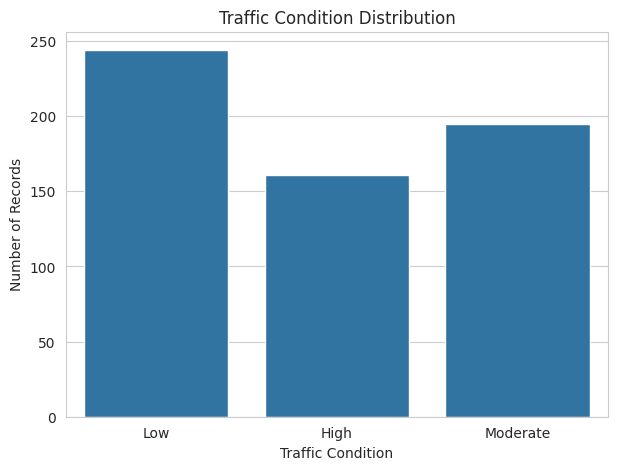

In [19]:
# Plot the number of observations in each traffic condition

plt.figure(figsize=(7, 5))

sns.countplot(data=df, x="Traffic_Condition")

plt.title("Traffic Condition Distribution")
plt.xlabel("Traffic Condition")
plt.ylabel("Number of Records")

plt.show()

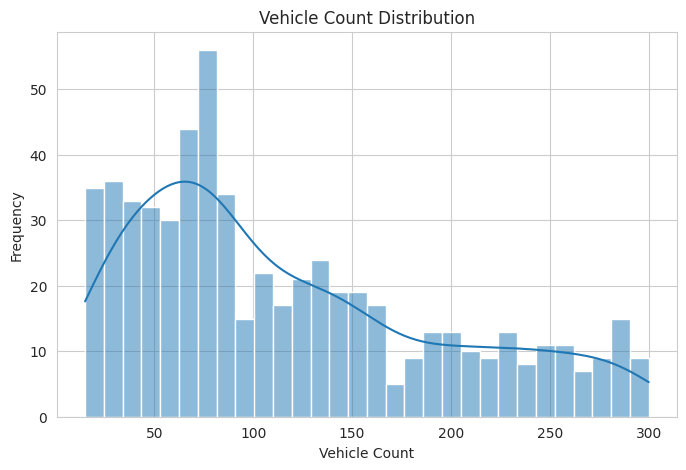

In [20]:
# Plot distribution of vehicle count

plt.figure(figsize=(8, 5))

sns.histplot(df["Vehicle_Count"].dropna(), bins=30, kde=True)

plt.title("Vehicle Count Distribution")
plt.xlabel("Vehicle Count")
plt.ylabel("Frequency")

plt.show()

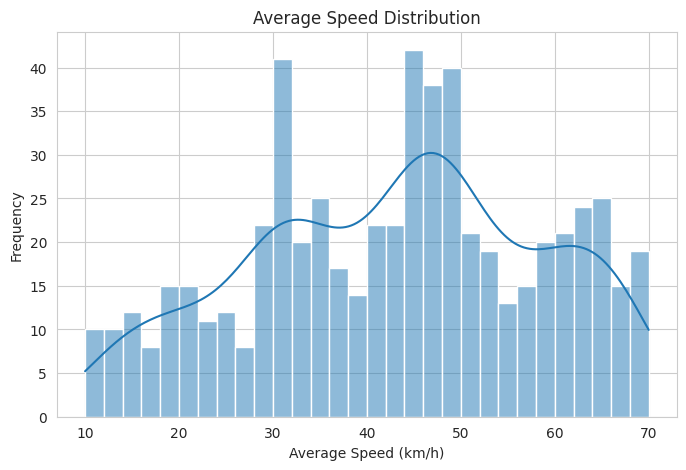

In [21]:
# Plot distribution of average speed

plt.figure(figsize=(8, 5))

sns.histplot(
    df["Average_Speed_kmph"].dropna(),
    bins=30,
    kde=True
)

plt.title("Average Speed Distribution")
plt.xlabel("Average Speed (km/h)")
plt.ylabel("Frequency")

plt.show()

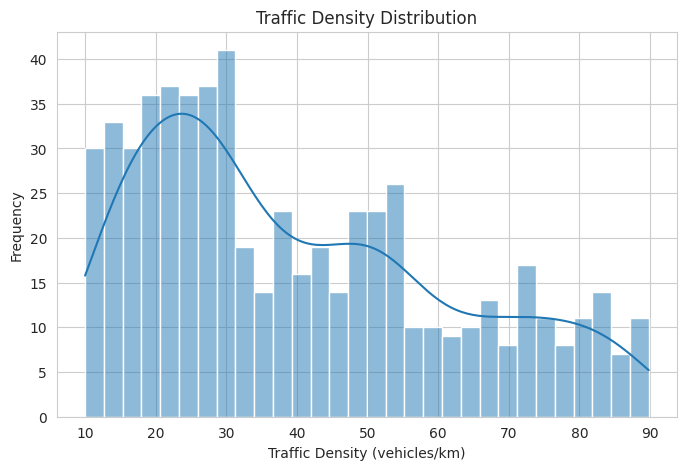

In [22]:
# Plot distribution of traffic density

plt.figure(figsize=(8, 5))

sns.histplot(
    df["Traffic_Density_veh_per_km"].dropna(),
    bins=30,
    kde=True
)

plt.title("Traffic Density Distribution")
plt.xlabel("Traffic Density (vehicles/km)")
plt.ylabel("Frequency")

plt.show()

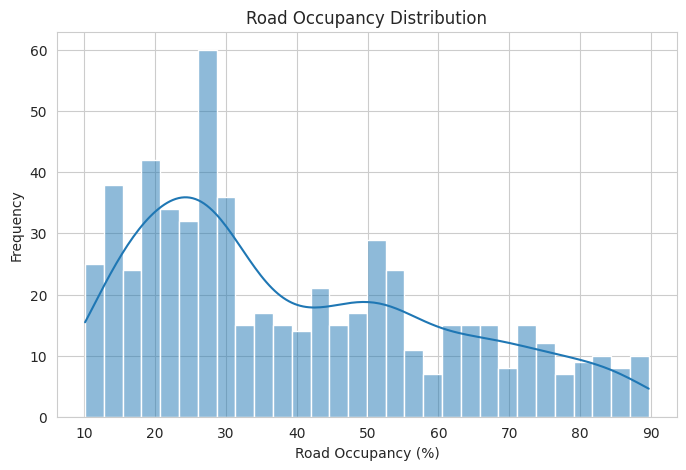

In [23]:
# Plot distribution of road occupancy

plt.figure(figsize=(8, 5))

sns.histplot(
    df["Road_Occupancy_percent"].dropna(),
    bins=30,
    kde=True
)

plt.title("Road Occupancy Distribution")
plt.xlabel("Road Occupancy (%)")
plt.ylabel("Frequency")

plt.show()

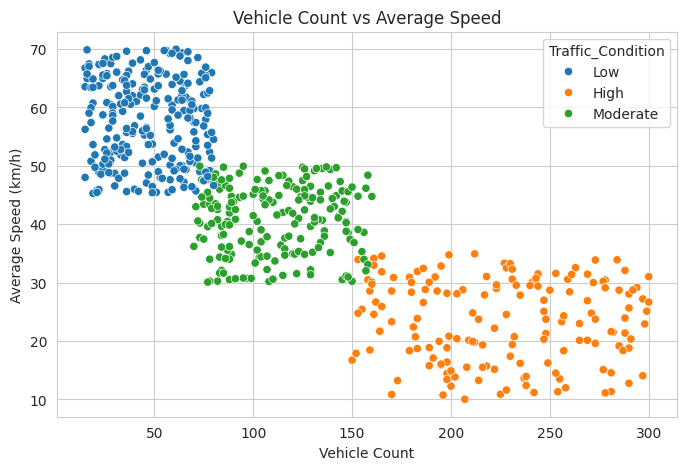

In [24]:
# Compare vehicle count and average speed

plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="Vehicle_Count",
    y="Average_Speed_kmph",
    hue="Traffic_Condition"
)

plt.title("Vehicle Count vs Average Speed")
plt.xlabel("Vehicle Count")
plt.ylabel("Average Speed (km/h)")

plt.show()

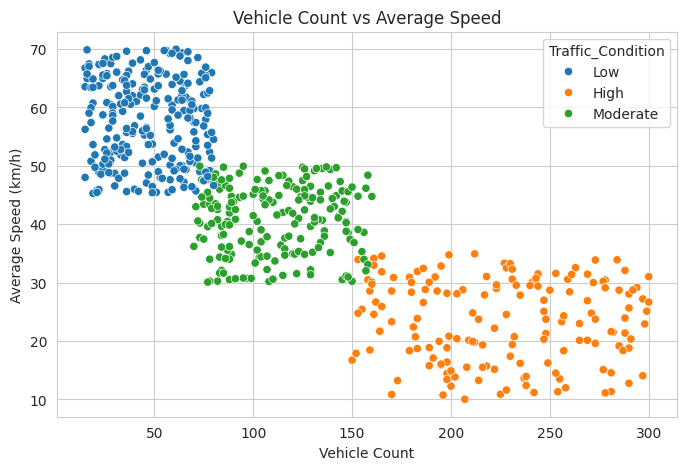

In [25]:
# Compare vehicle count and average speed

plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="Vehicle_Count",
    y="Average_Speed_kmph",
    hue="Traffic_Condition"
)

plt.title("Vehicle Count vs Average Speed")
plt.xlabel("Vehicle Count")
plt.ylabel("Average Speed (km/h)")

plt.show()

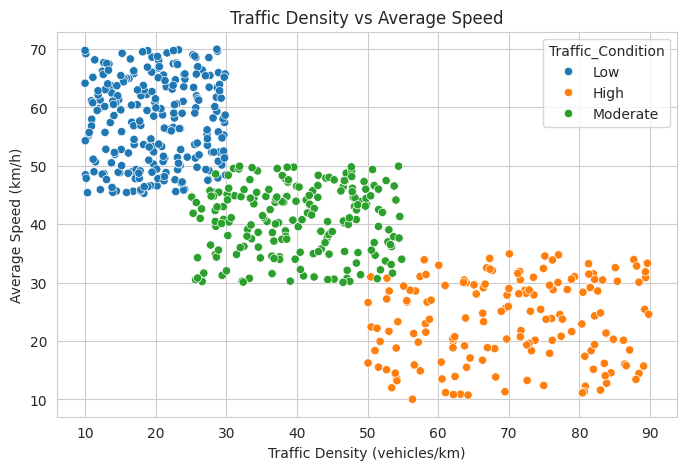

In [26]:
# Compare traffic density and average speed

plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="Traffic_Density_veh_per_km",
    y="Average_Speed_kmph",
    hue="Traffic_Condition"
)

plt.title("Traffic Density vs Average Speed")
plt.xlabel("Traffic Density (vehicles/km)")
plt.ylabel("Average Speed (km/h)")

plt.show()

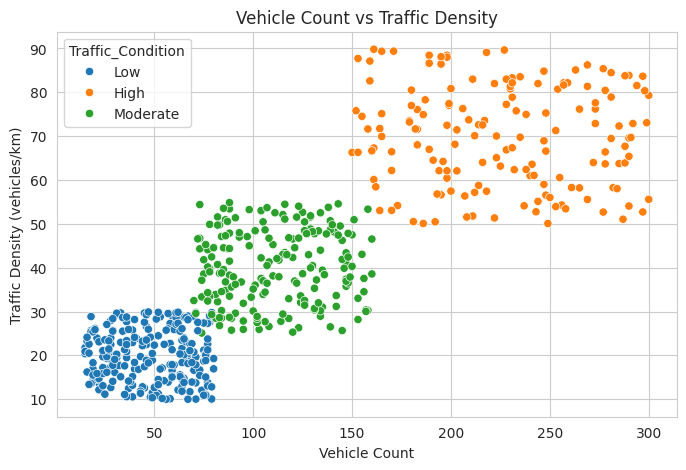

In [27]:
# Compare vehicle count and traffic density

plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="Vehicle_Count",
    y="Traffic_Density_veh_per_km",
    hue="Traffic_Condition"
)

plt.title("Vehicle Count vs Traffic Density")
plt.xlabel("Vehicle Count")
plt.ylabel("Traffic Density (vehicles/km)")

plt.show()

In [28]:
# Select the main traffic features for analysis

features = [
    "Vehicle_Count",
    "Average_Speed_kmph",
    "Traffic_Density_veh_per_km",
    "Road_Occupancy_percent"
]

traffic_data = df[features]

traffic_data.head()

,Vehicle_Count,Average_Speed_kmph,Traffic_Density_veh_per_km,Road_Occupancy_percent
0,19.0,53.63,16.95,10.64
1,282.0,21.52,58.25,64.57
2,114.0,36.43,27.77,39.43
3,125.0,47.47,52.63,26.83
4,22.0,63.71,13.69,14.19


In [29]:
# Calculate correlation between traffic features

correlation = traffic_data.corr()

print(correlation)

                            Vehicle_Count  Average_Speed_kmph  \
Vehicle_Count                    1.000000           -0.825893   
Average_Speed_kmph              -0.825893            1.000000   
Traffic_Density_veh_per_km       0.851337           -0.815803   
Road_Occupancy_percent           0.847710           -0.820188   

                            Traffic_Density_veh_per_km  Road_Occupancy_percent  
Vehicle_Count                                 0.851337                0.847710  
Average_Speed_kmph                           -0.815803               -0.820188  
Traffic_Density_veh_per_km                    1.000000                0.850963  
Road_Occupancy_percent                        0.850963                1.000000  


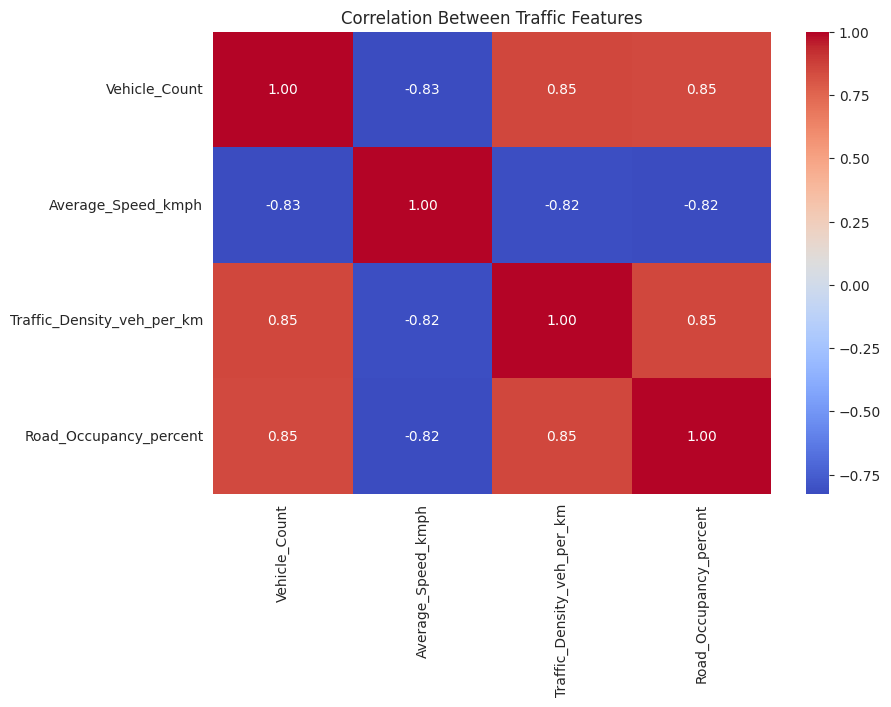

In [30]:
# Create a correlation heatmap

plt.figure(figsize=(9, 6))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Between Traffic Features")

plt.show()

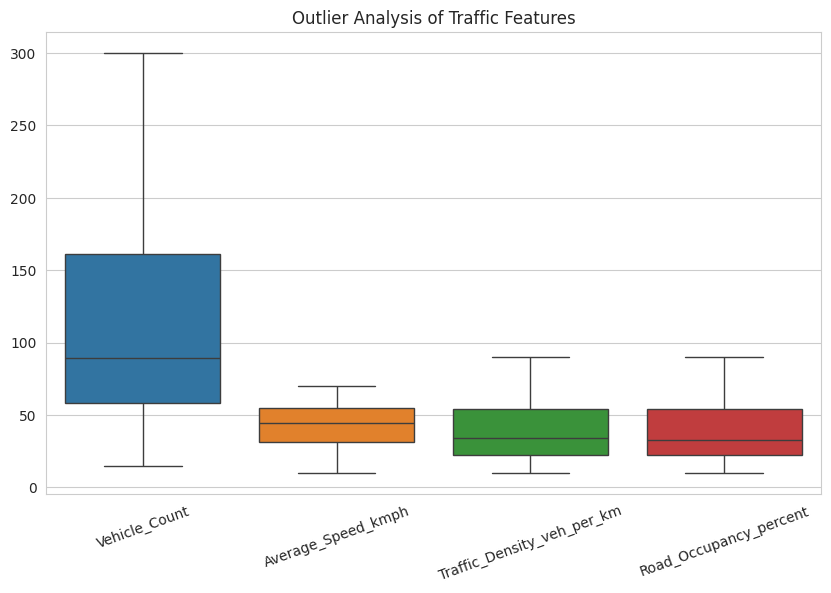

In [31]:
# Create boxplots for the main traffic features

plt.figure(figsize=(10, 6))

sns.boxplot(data=traffic_data)

plt.title("Outlier Analysis of Traffic Features")
plt.xticks(rotation=20)

plt.show()

In [32]:
# Calculate average traffic values for each condition

condition_summary = df.groupby("Traffic_Condition")[features].mean()

condition_summary

,Vehicle_Count,Average_Speed_kmph,Traffic_Density_veh_per_km,Road_Occupancy_percent
Traffic_Condition,,,,
High,226.500000,23.426125,70.122830,69.238137
Low,47.946058,57.613430,20.126694,20.387623
Moderate,111.635897,40.724639,40.150718,39.843487


In [33]:
# Calculate average vehicle count for each hour

hourly_traffic = df.groupby("Hour")["Vehicle_Count"].mean()

hourly_traffic

,Vehicle_Count
Hour,
0,116.545455
1,108.040000
2,138.590909
3,127.333333
4,92.875000
5,91.095238
6,127.045455
7,107.000000
8,94.875000


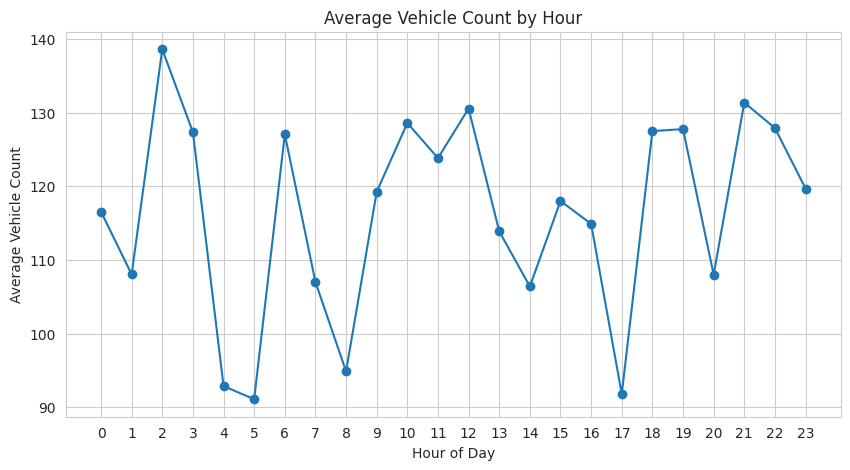

In [34]:
# Plot average vehicle count by hour

plt.figure(figsize=(10, 5))

plt.plot(
    hourly_traffic.index,
    hourly_traffic.values,
    marker="o"
)

plt.title("Average Vehicle Count by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Average Vehicle Count")

plt.xticks(range(0, 24))

plt.grid(True)

plt.show()

In [35]:
# Final dataset information before machine learning

print("Dataset Shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

print("\nTraffic Conditions:")
print(df["Traffic_Condition"].value_counts())

Dataset Shape: (600, 8)

Columns:
['Record_ID', 'Hour', 'Day_of_Week', 'Vehicle_Count', 'Average_Speed_kmph', 'Traffic_Density_veh_per_km', 'Road_Occupancy_percent', 'Traffic_Condition']

Missing Values:
Record_ID                     0
Hour                          0
Day_of_Week                   0
Vehicle_Count                 4
Average_Speed_kmph            4
Traffic_Density_veh_per_km    4
Road_Occupancy_percent        0
Traffic_Condition             0
dtype: int64

Duplicate Rows:
0

Traffic Conditions:
Traffic_Condition
Low         244
Moderate    195
High        161
Name: count, dtype: int64


In [36]:
# Select the features we will use for clustering

features = [
    'Vehicle_Count',
    'Average_Speed_kmph',
    'Traffic_Density_veh_per_km',
    'Road_Occupancy_percent'
]

X = df[features]

print("Selected features:")
print(X.head())

Selected features:
   Vehicle_Count  Average_Speed_kmph  Traffic_Density_veh_per_km  \
0           19.0               53.63                       16.95   
1          282.0               21.52                       58.25   
2          114.0               36.43                       27.77   
3          125.0               47.47                       52.63   
4           22.0               63.71                       13.69   

   Road_Occupancy_percent  
0                   10.64  
1                   64.57  
2                   39.43  
3                   26.83  
4                   14.19  


In [37]:
# Feature Scaling for Clustering

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("Original feature shape:", X.shape)
print("Scaled feature shape:", X_scaled.shape)

print("\nFirst 5 scaled rows:")
print(X_scaled[:5])

Original feature shape: (600, 4)
Scaled feature shape: (600, 4)

First 5 scaled rows:
[[-1.26042632  0.6952218  -1.06015129 -1.3666363 ]
 [ 2.13190378 -1.39270744  0.83805855  1.15924518]
 [-0.03505994 -0.42319561 -0.56284789 -0.01821932]
 [ 0.10682459  0.29467231  0.57975494 -0.60835666]
 [-1.22173054  1.35066642 -1.20998578 -1.20036745]]


In [39]:
# Handle Missing Values in Clustering Features

from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="median")

X_imputed = imputer.fit_transform(X)

print("Missing values before imputation:")
print(X.isnull().sum())

print("\nMissing values after imputation:")
print(pd.DataFrame(X_imputed, columns=features).isnull().sum())

Missing values before imputation:
Vehicle_Count                 4
Average_Speed_kmph            4
Traffic_Density_veh_per_km    4
Road_Occupancy_percent        0
dtype: int64

Missing values after imputation:
Vehicle_Count                 0
Average_Speed_kmph            0
Traffic_Density_veh_per_km    0
Road_Occupancy_percent        0
dtype: int64


In [41]:
# Scale the Imputed Features

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X_imputed)

print("Scaled data shape:", X_scaled.shape)
print("Any missing values:", pd.DataFrame(X_scaled).isnull().sum().sum())

Scaled data shape: (600, 4)
Any missing values: 0


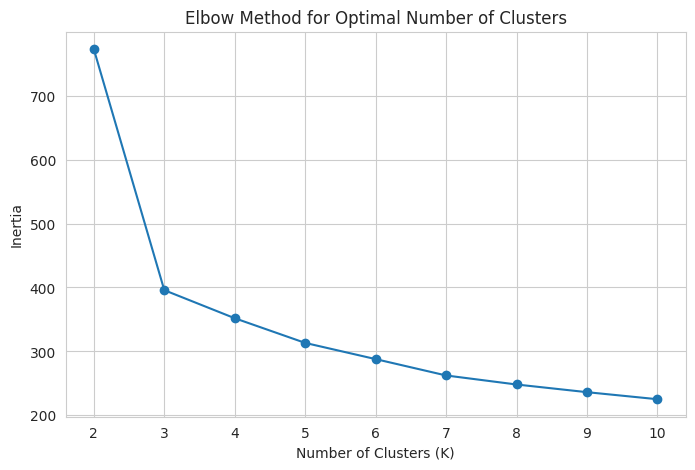

In [42]:
# Finding the Optimal Number of Clusters using the Elbow Method

from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_scaled)

    inertia.append(kmeans.inertia_)

# Plot the Elbow Curve

plt.figure(figsize=(8, 5))

plt.plot(K_range, inertia, marker="o")

plt.title("Elbow Method for Optimal Number of Clusters")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")

plt.xticks(K_range)
plt.grid(True)

plt.show()

In [43]:
# K-Means Clustering

from sklearn.cluster import KMeans

optimal_k = 3

kmeans = KMeans(
    n_clusters=optimal_k,
    random_state=42,
    n_init=10
)

kmeans_labels = kmeans.fit_predict(X_scaled)

print("K-Means clustering completed!")
print("Number of clusters:", optimal_k)
print("\nCluster counts:")
print(pd.Series(kmeans_labels).value_counts().sort_index())

K-Means clustering completed!
Number of clusters: 3

Cluster counts:
0    195
1    161
2    244
Name: count, dtype: int64


In [44]:
# Analyze K-Means Cluster Profiles

clustered_data = X.copy()
clustered_data["KMeans_Cluster"] = kmeans_labels

cluster_summary = clustered_data.groupby("KMeans_Cluster")[features].mean()

print("K-Means Cluster Profiles:")
print(cluster_summary)

K-Means Cluster Profiles:
                Vehicle_Count  Average_Speed_kmph  Traffic_Density_veh_per_km  \
KMeans_Cluster                                                                  
0                  111.635897           40.724639                   40.150718   
1                  226.500000           23.426125                   70.122830   
2                   47.946058           57.613430                   20.126694   

                Road_Occupancy_percent  
KMeans_Cluster                          
0                            39.843487  
1                            69.238137  
2                            20.387623  


In [45]:
# Number of records in each K-Means cluster

print("\nNumber of records in each cluster:")
print(clustered_data["KMeans_Cluster"].value_counts().sort_index())


Number of records in each cluster:
KMeans_Cluster
0    195
1    161
2    244
Name: count, dtype: int64


In [46]:
# Evaluate K-Means Clustering

from sklearn.metrics import silhouette_score, davies_bouldin_score

silhouette = silhouette_score(X_scaled, kmeans_labels)
davies_bouldin = davies_bouldin_score(X_scaled, kmeans_labels)

print("K-Means Evaluation Results")
print("---------------------------")
print("Silhouette Score:", round(silhouette, 4))
print("Davies-Bouldin Index:", round(davies_bouldin, 4))

K-Means Evaluation Results
---------------------------
Silhouette Score: 0.5214
Davies-Bouldin Index: 0.7045


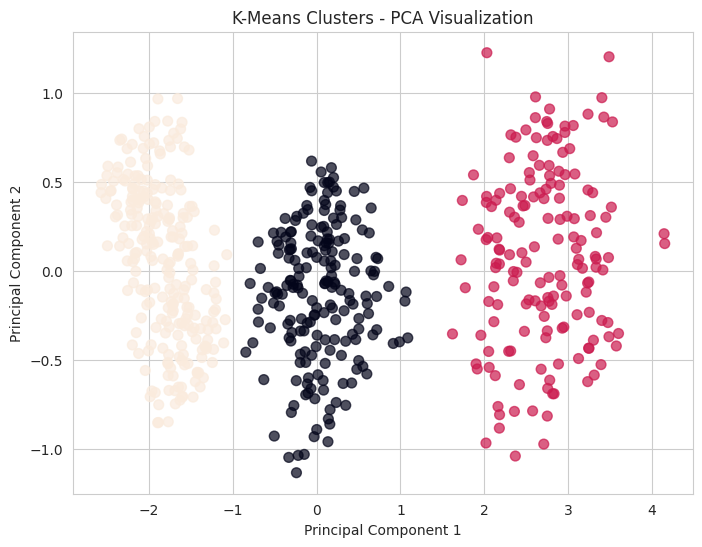

In [47]:
# Visualize K-Means Clusters using PCA

from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8, 6))

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=kmeans_labels,
    s=50,
    alpha=0.7
)

plt.title("K-Means Clusters - PCA Visualization")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.show()

In [48]:
# DBSCAN Clustering

from sklearn.cluster import DBSCAN

dbscan = DBSCAN(
    eps=0.5,
    min_samples=5
)

dbscan_labels = dbscan.fit_predict(X_scaled)

print("DBSCAN clustering completed!")

print("\nCluster labels:")
print(pd.Series(dbscan_labels).value_counts().sort_index())

DBSCAN clustering completed!

Cluster labels:
-1     41
 0    439
 1     78
 2     22
 3      9
 4      6
 5      5
Name: count, dtype: int64


In [49]:
# Analyze DBSCAN Cluster Profiles

dbscan_data = X.copy()
dbscan_data["DBSCAN_Cluster"] = dbscan_labels

dbscan_summary = dbscan_data.groupby("DBSCAN_Cluster")[features].mean()

print("DBSCAN Cluster Profiles:")
print(dbscan_summary)

DBSCAN Cluster Profiles:
                Vehicle_Count  Average_Speed_kmph  Traffic_Density_veh_per_km  \
DBSCAN_Cluster                                                                  
-1                 218.800000           21.930750                   72.658974   
 0                  76.431193           50.098693                   29.061899   
 1                 243.102564           23.844231                   71.573077   
 2                 184.545455           23.346364                   65.210909   
 3                 231.666667           29.803333                   77.131111   
 4                 252.500000           14.613333                   55.290000   
 5                 173.200000           28.314000                   54.514000   

                Road_Occupancy_percent  
DBSCAN_Cluster                          
-1                           71.174146  
 0                           29.029749  
 1                           70.897051  
 2                           58.320909  

In [50]:
# Number of records in each DBSCAN cluster

print("\nNumber of records in each DBSCAN cluster:")
print(dbscan_data["DBSCAN_Cluster"].value_counts().sort_index())


Number of records in each DBSCAN cluster:
DBSCAN_Cluster
-1     41
 0    439
 1     78
 2     22
 3      9
 4      6
 5      5
Name: count, dtype: int64


In [51]:
# Evaluate DBSCAN Clustering

from sklearn.metrics import silhouette_score, davies_bouldin_score

# Identify non-noise points
non_noise = dbscan_labels != -1

# Get the labels of non-noise points
dbscan_valid_labels = dbscan_labels[non_noise]
X_dbscan_valid = X_scaled[non_noise]

# Count actual clusters excluding noise
n_clusters = len(set(dbscan_valid_labels))

print("Number of DBSCAN clusters:", n_clusters)
print("Number of noise points:", sum(dbscan_labels == -1))

if n_clusters >= 2:
    dbscan_silhouette = silhouette_score(
        X_dbscan_valid,
        dbscan_valid_labels
    )

    dbscan_davies_bouldin = davies_bouldin_score(
        X_dbscan_valid,
        dbscan_valid_labels
    )

    print("\nDBSCAN Evaluation Results")
    print("-------------------------")
    print("Silhouette Score:", round(dbscan_silhouette, 4))
    print("Davies-Bouldin Index:", round(dbscan_davies_bouldin, 4))
else:
    print("\nDBSCAN produced fewer than 2 clusters.")
    print("Silhouette and Davies-Bouldin scores cannot be calculated.")

Number of DBSCAN clusters: 6
Number of noise points: 41

DBSCAN Evaluation Results
-------------------------
Silhouette Score: 0.3897
Davies-Bouldin Index: 1.17


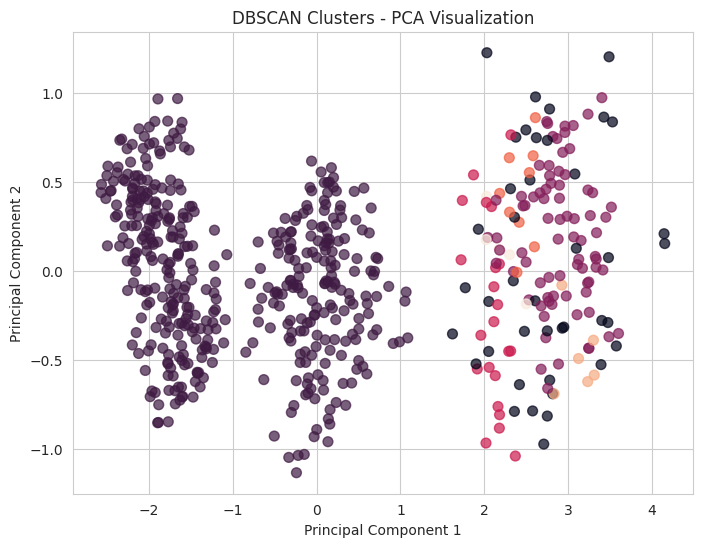

In [52]:
# Visualize DBSCAN Clusters using PCA

plt.figure(figsize=(8, 6))

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=dbscan_labels,
    s=50,
    alpha=0.7
)

plt.title("DBSCAN Clusters - PCA Visualization")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.show()

In [53]:
# Final Comparison of K-Means and DBSCAN

comparison = pd.DataFrame({
    "Algorithm": ["K-Means", "DBSCAN"],
    "Number of Clusters": [
        len(set(kmeans_labels)),
        len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
    ],
    "Noise Points": [
        0,
        sum(dbscan_labels == -1)
    ],
    "Silhouette Score": [
        silhouette,
        dbscan_silhouette
    ],
    "Davies-Bouldin Index": [
        davies_bouldin,
        dbscan_davies_bouldin
    ]
})

comparison

,Algorithm,Number of Clusters,Noise Points,Silhouette Score,Davies-Bouldin Index
0,K-Means,3,0,0.521368,0.704532
1,DBSCAN,6,41,0.389677,1.169987


In [54]:
# Final Cluster Profiles

print("K-Means Cluster Profiles:")
display(cluster_summary)

print("\nDBSCAN Cluster Profiles:")
display(dbscan_summary)

K-Means Cluster Profiles:


,Vehicle_Count,Average_Speed_kmph,Traffic_Density_veh_per_km,Road_Occupancy_percent
KMeans_Cluster,,,,
0,111.635897,40.724639,40.150718,39.843487
1,226.500000,23.426125,70.122830,69.238137
2,47.946058,57.613430,20.126694,20.387623



DBSCAN Cluster Profiles:


,Vehicle_Count,Average_Speed_kmph,Traffic_Density_veh_per_km,Road_Occupancy_percent
DBSCAN_Cluster,,,,
-1,218.800000,21.930750,72.658974,71.174146
0,76.431193,50.098693,29.061899,29.029749
1,243.102564,23.844231,71.573077,70.897051
2,184.545455,23.346364,65.210909,58.320909
3,231.666667,29.803333,77.131111,56.973333
4,252.500000,14.613333,55.290000,80.985000
5,173.200000,28.314000,54.514000,83.500000
